# 03 — Summary (OAT + Group study 종합)

01_oat 와 02_group_study 결과를 종합해 발표 자료 4종 생성. **둘 다 끝난 후 1회 실행**.

- **입력**: `4_output/0_baseline/oat/master.csv`, `4_output/0_baseline/group/{optuna.db, param_importance.csv}`
- **출력**: `4_output/0_baseline/summary/{tornado.png, group_importance.png, comparison.csv, summary_report.png}`
- **참조**: [strategy.md §8·§9](strategy.md)

## 1. 환경 + 산출물 로드

In [1]:
import os, sys
RESUME = True   # 기존 Optuna study(db)에 이어서 학습할지 (필요시 config 셀에서 덮어씀)
# ── Colab이면 코드 번들 1개(code.zip)만 받아 풀기 — 데이터·경로·폰트는 setup.py가 처리 ──
try:
    import google.colab  # Colab에서만 import 성공
    GDRIVE_CODE_ID = '1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I'  # code.zip = setup.py+requirements+utils+2_preprocessing+3_modeling 지원코드
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip -q install gdown')
        os.system(f'gdown {GDRIVE_CODE_ID} -O /content/code.zip')
        os.system('unzip -qo /content/code.zip -d /content/project')
    os.chdir('/content/project')
except ImportError:
    pass
# ── 공통: cwd에서 위로 setup.py(+utils/)를 자동탐색해 실행 (노트북 깊이·드라이브 위치 무관) ──
_d = os.getcwd()
while not (os.path.exists(os.path.join(_d, 'setup.py')) and os.path.isdir(os.path.join(_d, 'utils'))):
    _p = os.path.dirname(_d)
    if _p == _d:
        raise RuntimeError('프로젝트 루트(setup.py + utils/)를 못 찾음 — cwd 확인')
    _d = _p
if _d not in sys.path:
    sys.path.insert(0, _d)
import runpy
runpy.run_path(os.path.join(_d, 'setup.py'))

from utils.config import PROJECT_ROOT

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

# 01_oat / 02_group_study가 저장한 산출물 경로
BASE = os.path.join(PROJECT_ROOT, '4_output', '0_baseline')
OAT_CSV       = os.path.join(BASE, 'oat',   'master.csv')          # OAT 결과 행들
GROUP_DB      = os.path.join(BASE, 'group', 'optuna.db')           # group study DB
GROUP_IMP_CSV = os.path.join(BASE, 'group', 'param_importance.csv')# fANOVA 축 중요도
SUMMARY_DIR   = os.path.join(BASE, 'summary')                      # 발표 산출물 출력 폴더
os.makedirs(SUMMARY_DIR, exist_ok=True)

oat = pd.read_csv(OAT_CSV)
group_imp = pd.read_csv(GROUP_IMP_CSV)
study = optuna.load_study(study_name='baseline_group', storage=f'sqlite:///{GROUP_DB}')

print(f'OAT master: {len(oat)} rows, axes={oat["axis"].nunique()}')
print(f'Group study: {len(study.trials)} trials')
print(f'Group importance: {len(group_imp)} axes')

setup 완료
OAT master: 32 rows, axes=12
Group study: 300 trials
Group importance: 11 axes


## 2. OAT — Tornado plot

축별 OOF RMSE range (max − min) 정렬, 가로 bar. **각 축의 reference 옵션도 후보에 포함**해서 range를 계산한다 (안 하면 reference보다 나쁜 단일 대안이 best로 찍힘). agg_preset은 reg_level='unit' 셀들로 자기완결.

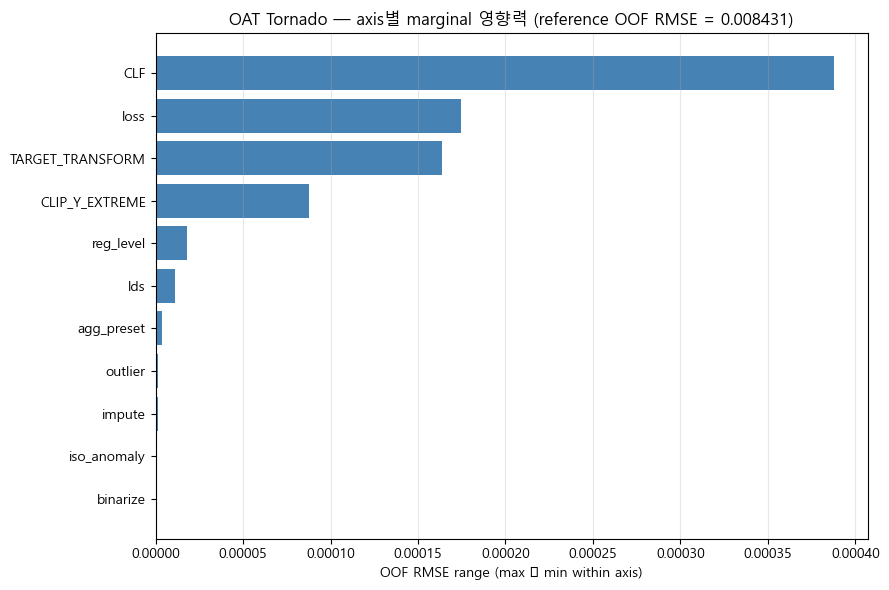

axis별 marginal Δ (OOF RMSE):
  CLF                  Δ 0.000388
  loss                 Δ 0.000175
  TARGET_TRANSFORM     Δ 0.000164
  CLIP_Y_EXTREME       Δ 0.000087
  reg_level            Δ 0.000018
  lds                  Δ 0.000011
  agg_preset           Δ 0.000004
  outlier              Δ 0.000002
  impute               Δ 0.000001
  iso_anomaly          Δ 0.000001
  binarize             Δ 0.000000


In [2]:
# 비교 지표 = OOF RMSE (train 5-fold CV).
#   group study objective도 oof_rmse라 통일 — strategy_common: best 탐색은 train OOF 기준.
#   val/test는 아래 comparison 표에 참고 컬럼으로만 표시 (직접 줄세우면 cherry-picking).
METRIC = 'oof_rmse'

# 각 (axis, option)의 OOF RMSE를 seed 평균으로 안정화 (baseline은 seed 1개라 사실상 그대로)
ablation = (
    oat[oat['axis'] != 'reference']
    .groupby(['axis', 'option'])[METRIC]
    .mean()
    .reset_index()
)
ref_val = oat[oat['axis'] == 'reference'][METRIC].mean()   # 기준점 RMSE (reference cfg)

# ★ 각 축의 reference 옵션도 비교 후보에 포함해야 range/best가 올바르다.
#   (안 그러면 reference보다 나쁜 단일 대안이 그 축의 "best"로 찍힌다)
#   agg_preset은 reg_level='unit' 셀들로 자기완결 — reference(position)에선 no-op이라 제외.
ref_cfg = oat[oat['axis'] == 'reference'].iloc[0]
ref_opt_rows = []
for ax_name in ablation['axis'].unique():
    if ax_name == 'agg_preset':
        continue
    ref_opt = ref_cfg[f'cfg_{ax_name}']
    has_ref_opt = ((ablation['axis'] == ax_name) & (ablation['option'].astype(str) == str(ref_opt))).any()
    if not has_ref_opt:
        ref_opt_rows.append({'axis': ax_name, 'option': ref_opt, METRIC: ref_val})
if ref_opt_rows:
    ablation = pd.concat([ablation, pd.DataFrame(ref_opt_rows)], ignore_index=True)

# 축별 영향력 = 그 축 옵션들 사이의 OOF RMSE range(max - min). 작은 순으로 정렬
axis_range = (
    ablation.groupby('axis')[METRIC]
    .agg(lambda s: s.max() - s.min())
    .sort_values()
)

# 가로 막대(tornado): 위로 갈수록 영향력 큰 축
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(axis_range.index, axis_range.values, color='steelblue')
ax.set_xlabel('OOF RMSE range (max − min within axis)')
ax.set_title(f'OAT Tornado — axis별 marginal 영향력 (reference OOF RMSE = {ref_val:.6f})')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, 'tornado.png'), dpi=120, bbox_inches='tight')
plt.show()

print('axis별 marginal Δ (OOF RMSE):')
for ax_name, delta in axis_range[::-1].items():   # 영향력 큰 축부터 출력
    print(f'  {ax_name:20s} Δ {delta:.6f}')


## 3. Group study — Param importance

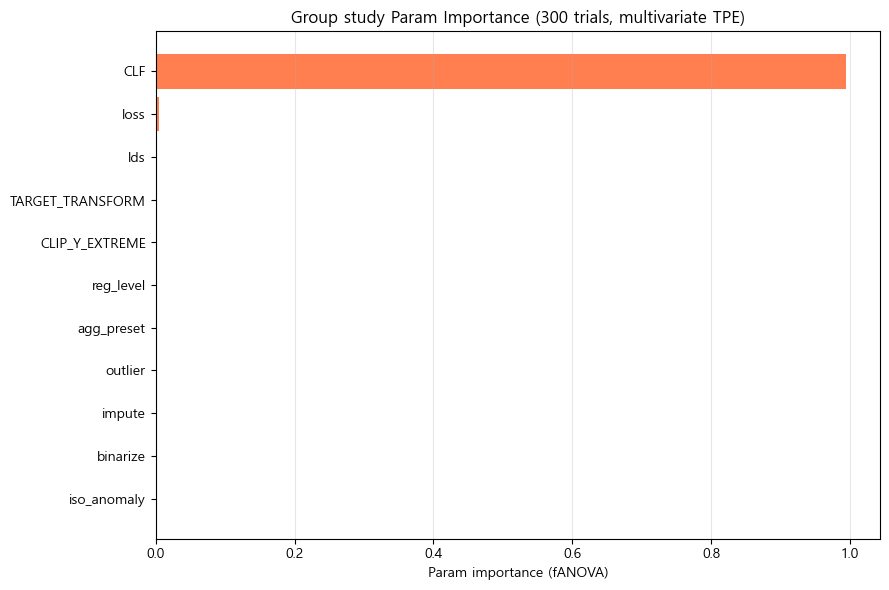

In [3]:
# group study의 fANOVA 중요도를 가로 막대로 (작은 순 정렬 → 위로 갈수록 중요)
imp_sorted = group_imp.sort_values('importance')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_sorted['axis'], imp_sorted['importance'], color='coral')
ax.set_xlabel('Param importance (fANOVA)')
ax.set_title(f'Group study Param Importance ({len(study.trials)} trials, multivariate TPE)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, 'group_importance.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. 비교표 (comparison.csv)

OAT marginal best vs Group study best. 일치하면 marginal 신뢰성 ↑.

In [4]:
# OAT 쪽 "축별 최적 옵션": 그 축에서 OOF RMSE가 가장 낮은 option과 그 값 (reference 옵션도 후보에 포함됨)
oat_min = ablation.sort_values(METRIC).groupby('axis').first()
oat_best_option = oat_min['option'].rename('oat_marginal_best')
oat_best_rmse   = oat_min[METRIC].rename('oat_best_oof_rmse')
ref_val_series  = pd.Series({ax: ref_val for ax in oat_best_option.index},
                            name='reference_oof_rmse')

# Group study 쪽 "최적": best trial(=OOF RMSE 최소)이 고른 축별 값 + 그 trial의 oof/val/test RMSE
best_trial = study.best_trial
group_best_option = pd.Series(best_trial.params, name='group_best')
group_best_oof = pd.Series({ax: best_trial.value for ax in group_best_option.index},
                           name='group_best_oof_rmse')   # objective = oof_rmse
group_best_val = pd.Series(
    {ax: best_trial.user_attrs.get('val_rmse') for ax in group_best_option.index},
    name='group_best_val_rmse',
)
group_best_test = pd.Series(
    {ax: best_trial.user_attrs.get('test_rmse') for ax in group_best_option.index},
    name='group_best_test_rmse',
)

# 두 방식의 축별 선택을 나란히 놓고 일치 여부(agree) 표시 → OAT marginal의 신뢰성 점검
# 주의: agg_preset은 group best trial이 reg_level='position'이면 의미 없는 값이라 agree 해석에서 제외하고 봐야 함
comparison = pd.concat(
    [oat_best_option, oat_best_rmse, ref_val_series,
     group_best_option, group_best_oof, group_best_val, group_best_test],
    axis=1,
)
comparison['agree'] = (comparison['oat_marginal_best'].astype(str)
                       == comparison['group_best'].astype(str))
comparison.to_csv(os.path.join(SUMMARY_DIR, 'comparison.csv'))
comparison


,oat_marginal_best,oat_best_oof_rmse,reference_oof_rmse,group_best,group_best_oof_rmse,group_best_val_rmse,group_best_test_rmse,agree
CLF,proba+filter,0.008291,0.008431,off,0.008257,0.005733,0.008435,False
CLIP_Y_EXTREME,False,0.008344,0.008431,True,0.008257,0.005733,0.008435,False
TARGET_TRANSFORM,log1p,0.008267,0.008431,yeo-johnson,0.008257,0.005733,0.008435,False
agg_preset,P04_mean,0.008447,0.008431,P10_full8,0.008257,0.005733,0.008435,False
binarize,False,0.008431,0.008431,True,0.008257,0.005733,0.008435,False
impute,median,0.008430,0.008431,spatial,0.008257,0.005733,0.008435,False
iso_anomaly,True,0.008430,0.008431,True,0.008257,0.005733,0.008435,True
lds,False,0.008431,0.008431,False,0.008257,0.005733,0.008435,True
loss,tweedie,0.008263,0.008431,tweedie,0.008257,0.005733,0.008435,True
outlier,none,0.008429,0.008431,grubbs,0.008257,0.005733,0.008435,False


## 5. 발표용 종합 1장 (summary_report.png)

tornado + param importance + 핵심 메트릭을 1장에.

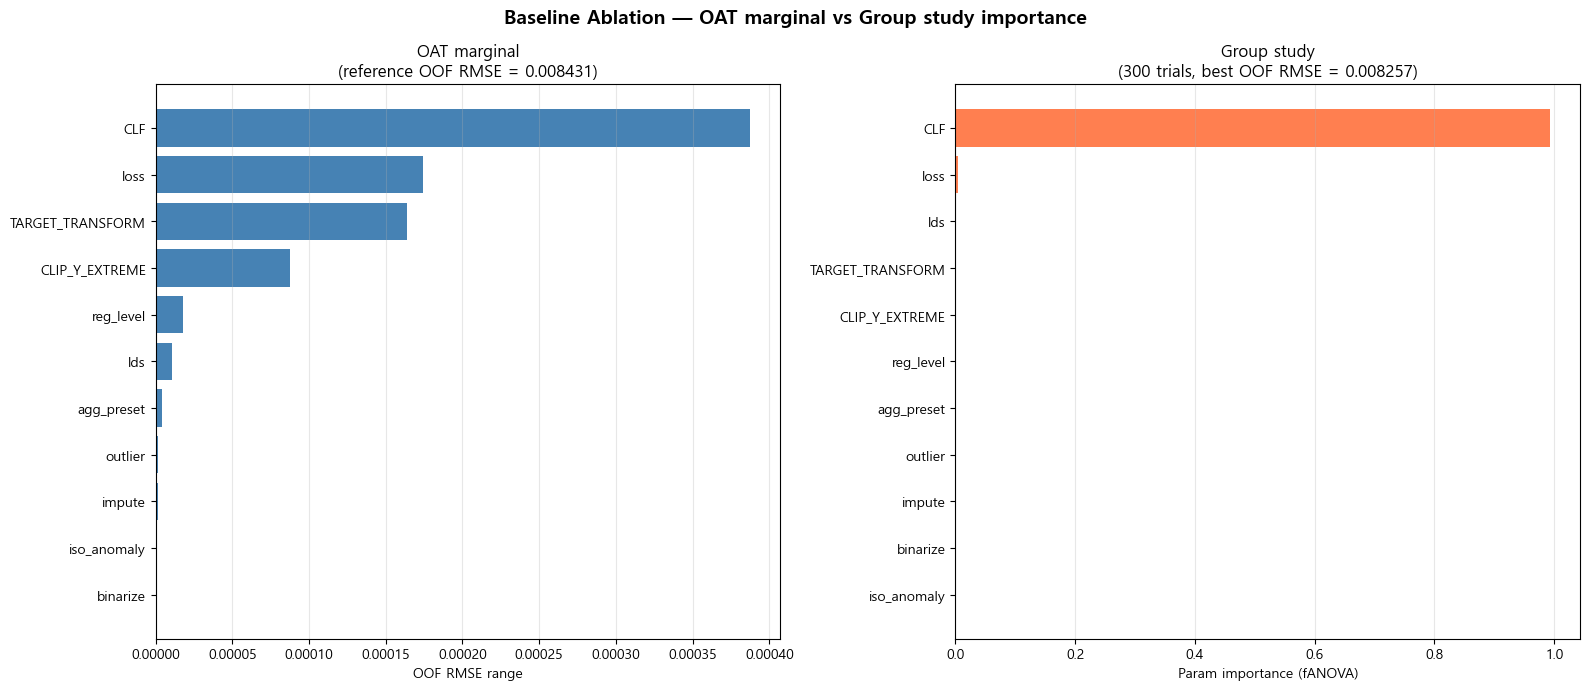


발표 산출물 4종 → c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\baseline\summary
  tornado.png                    35.2 KB
  group_importance.png           31.2 KB
  comparison.csv                 1.5 KB
  summary_report.png             62.4 KB


In [5]:
fig, axes_pl = plt.subplots(1, 2, figsize=(16, 7))

# 좌: OAT tornado (위 cell 4와 동일 데이터 — OOF RMSE 기준)
axes_pl[0].barh(axis_range.index, axis_range.values, color='steelblue')
axes_pl[0].set_xlabel('OOF RMSE range')
axes_pl[0].set_title(f'OAT marginal\n(reference OOF RMSE = {ref_val:.6f})')
axes_pl[0].grid(alpha=0.3, axis='x')

# 우: Group study fANOVA 중요도 (위 cell 6과 동일 데이터)
axes_pl[1].barh(imp_sorted['axis'], imp_sorted['importance'], color='coral')
axes_pl[1].set_xlabel('Param importance (fANOVA)')
axes_pl[1].set_title(f'Group study\n({len(study.trials)} trials, best OOF RMSE = {study.best_value:.6f})')
axes_pl[1].grid(alpha=0.3, axis='x')

fig.suptitle('Baseline Ablation — OAT marginal vs Group study importance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, 'summary_report.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'\n발표 산출물 4종 → {SUMMARY_DIR}')
for f in ['tornado.png', 'group_importance.png', 'comparison.csv', 'summary_report.png']:
    p = os.path.join(SUMMARY_DIR, f)
    print(f'  {f:30s} {os.path.getsize(p)/1024:.1f} KB')
